# 041 回归与优化阶段项目

先检查契约，再在新内核里依次运行。所有教学数据是原创合成数据。本Notebook实际重算行账本、优化路径、选择与覆盖、独立审计、计时及PNG。它不是浏览器Jupyter UI的测试报告。

In [1]:
# FIRST CELL: standard-library-only full-byte contract before numerical imports.
from pathlib import Path
import hashlib
ROOT = Path.cwd()
EXPECTED = {'experiment.py': 'f02a7484f0ded7ef3c66e9e2408caa55989422b50a132555bc574d7e9ed65647', 'audit.py': '36ee17a66aa1ec44493d62dfe44ce7fbe99480d2c36b69cd2e8619ba1f91cbe5', 'benchmark.py': '6141774b841297bd44ac443f3a91fab82322ec7c79e8a4a7dde17cb2f69301d1', 'build_assets.py': '0a3c97d8a80b61c1bdb735657e346c023398ba5fbd3c11361e9096f77a38d898', 'requirements.txt': '53c2669b8df3804d23448a2397f8a97e0c03a72b20418df9dc0da0c5d77a4e64', 'data/config.json': 'f3f6187e20c0f67bd2c59e97c488334440af59017982c3264850951c3155eae1', 'data/hand.csv': '2c2c01bf91aabcf7d1c3b40f1fac38b2227e770dce39bc2981ae6749369cf897', 'data/benchmark.csv': '3f2e84b952d58e983bfdcdbc880d27235f502630d603a18025481ee6b3fe2595', 'data/selection.csv': '41b6bdc0dfeefba9803c2a97b995f3a257e836a8011b46f91853553037be802f'}
for relative, wanted in EXPECTED.items():
    path = ROOT / relative
    if not path.is_file() or hashlib.sha256(path.read_bytes()).hexdigest() != wanted:
        raise ValueError("Contract changed: " + relative + ". Restore originals or run a separate script experiment.")
print("All", len(EXPECTED), "contract files match; numerical work may start.")


All 9 contract files match; numerical work may start.


## 输入与目标
参数顺序是[w1,w2]。平均半平方损失加λ/2乘参数平方和。初值、步长与每行数据都先验证，后求解。

In [2]:
import os
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / "notebook_results" / "mpl-cache"))
import numpy as np
import experiment as e
import audit
import benchmark
from IPython.display import display, Image
h, b, d, s = e.load_inputs()
print("Validated row counts:", len(h), len(b), len(d))
print("Configuration:", s)


Validated row counts: 4 360 240
Configuration: {'schema_version': 1, 'hand_lambda': 0.5, 'hand_step': 0.25, 'initial': [0.0, 0.0], 'lambdas': [0.0, 0.001, 0.01, 0.1, 1.0, 10.0], 'max_epochs': 400, 'batch_size': 16, 'gradient_tolerance': 1e-06, 'adam_step': 0.04, 'seed': 4107, 'fd_steps': [0.01, 0.0001, 1e-06, 1e-08, 1e-10], 'coverage_repetitions': 600}


In [3]:
result = e.run_experiment(h, b, d, s)
for state in result["hand"]["states"]:
    print("State", state["state"], "w=", state["w"], "J=", state["objective"], "g=", state["gradient"])
    for row in state["rows"]:
        print(row)
print("Analytic references:", result["hand"]["references"])


State 0 w= [0.0, 0.0] J= 1.75 g= [-1.5, -2.5]
{'id': 1, 'x': [-1.0, -2.0], 'y': -2.0, 'prediction': 0.0, 'residual': 2.0, 'half_square': 2.0, 'mean_loss': 0.5, 'd_loss_d_residual': 2.0, 'd_residual_d_prediction': 1.0, 'd_prediction_d_w': [-1.0, -2.0], 'gradient_contribution': [-0.5, -1.0]}
{'id': 2, 'x': [-1.0, 0.0], 'y': -1.0, 'prediction': 0.0, 'residual': 1.0, 'half_square': 0.5, 'mean_loss': 0.125, 'd_loss_d_residual': 1.0, 'd_residual_d_prediction': 1.0, 'd_prediction_d_w': [-1.0, 0.0], 'gradient_contribution': [-0.25, 0.0]}
{'id': 3, 'x': [1.0, 0.0], 'y': 0.0, 'prediction': 0.0, 'residual': 0.0, 'half_square': 0.0, 'mean_loss': 0.0, 'd_loss_d_residual': 0.0, 'd_residual_d_prediction': 1.0, 'd_prediction_d_w': [1.0, 0.0], 'gradient_contribution': [0.0, 0.0]}
{'id': 4, 'x': [1.0, 2.0], 'y': 3.0, 'prediction': 0.0, 'residual': -3.0, 'half_square': 4.5, 'mean_loss': 1.125, 'd_loss_d_residual': -3.0, 'd_residual_d_prediction': 1.0, 'd_prediction_d_w': [1.0, 2.0], 'gradient_contributio

## 独立核验
Fraction、二维消元、库目标换算、复制样本、随机差分、输入守卫和原子失败保护。这里运行quick审计，完整新进程测试另由audit.py完成。

In [4]:
audit_result = audit.audit(full=False)
print("Fraction references:", audit_result["exact_hand"]["references"])
print("Math and library checks:", audit_result["mathematical"])
print("Pre-compute rejected cases:", audit_result["input_gates"]["precompute_rejections"])
print("Output protection:", audit_result["output_gates"])


Fraction references: {'ols': ['1/2', '1'], 'ridge': ['5/11', '9/11']}
Math and library checks: {'library_versions': {'numpy': '2.3.5', 'scipy': '1.17.0', 'sklearn': '1.8.0'}, 'library_and_replication': [{'lambda': 0.0, 'library_coefficient': [0.5000000000000002, 0.9999999999999996], 'max_difference': 0.0}, {'lambda': 0.001, 'library_coefficient': [0.4999995014960105, 0.9995004990024935], 'max_difference': 2.7755575615628914e-16}, {'lambda': 0.01, 'library_coefficient': [0.4999514610232016, 0.9950490243665662], 'max_difference': 1.1102230246251565e-16}, {'lambda': 0.1, 'library_coefficient': [0.4961832061068702, 0.9541984732824426], 'max_difference': 3.3306690738754696e-16}, {'lambda': 1.0, 'library_coefficient': [0.39999999999999997, 0.7], 'max_difference': 2.220446049250313e-16}, {'lambda': 10.0, 'library_coefficient': [0.11832061068702289, 0.1984732824427481], 'max_difference': 2.7755575615628914e-17}], 'random_gradient_trials': 32, 'max_random_gradient_error': 1.2015100026019354e-10

## 所有路径与真实失败
用完整梯度统一判断，预算耗尽保留为失败状态。不要仅比较更新次数。

In [5]:
for run in result["optimizers"]["runs"]:
    f = run["final"]
    print(run["case"], run["lambda"], run["method"], run["status"], "steps", f["epoch"], "rho", f["relative_gradient"], "gap", f["quadratic_gap"], "coef_error", f["coefficient_distance"])
print("Injected failure:", result["optimizers"]["injected_failure"]["status"])
print("Failure cost:", result["optimizers"]["injected_failure"]["cost"])


regular 0.0 gd gradient_tolerance steps 16 rho 5.480602659122039e-07 gap 4.448394411490886e-13 coef_error 1.1508855552713884e-06
regular 0.0 diagonal_gd gradient_tolerance steps 15 rho 4.0578275089388265e-07 gap 2.407459969870787e-13 coef_error 8.430767306534996e-07
regular 0.0 minibatch budget_exhausted steps 400 rho 0.017518984472611503 gap 0.000323407466800292 coef_error 0.02631909390473768
regular 0.0 adam gradient_tolerance steps 263 rho 8.445968706976389e-07 gap 7.924088212654891e-13 coef_error 1.3577001640057748e-06
regular 0.0 newton gradient_tolerance steps 1 rho 1.1707929989055128e-15 gap 6.879242166511806e-30 coef_error 3.567752681690486e-15
regular 0.1 gd gradient_tolerance steps 14 rho 9.281118725532816e-07 gap 1.110383754234549e-12 coef_error 1.6964066354963389e-06
regular 0.1 diagonal_gd gradient_tolerance steps 13 rho 8.404022666372293e-07 gap 8.997955663764651e-13 coef_error 1.5209038344114774e-06
regular 0.1 minibatch budget_exhausted steps 400 rho 0.01808408571948179

## 已锁定的预测与区间边界
选择函数不接受测试数组。测试上的OLS可以胜过验证所选Ridge，原结果必须保留。OLS区间是单独的未选参模拟。

In [6]:
selection = result["selection"]
print("Selected lambda:", selection["lock"]["selected_lambda"])
print("Lock SHA-256:", selection["lock_sha256"])
print("Test MSE:", selection["test"]["selected_mse"], "OLS baseline:", selection["test"]["ols_mse"])
print("Coverage:", result["coverage"]["summary"])


Selected lambda: 0.1
Lock SHA-256: 822e1bc2e34b662d4269535a76a44a49146936d9786a506f34203600d5292485
Test MSE: 0.7750543393804552 OLS baseline: 0.7677543366091001
Coverage: {'mean_covered': {'covered': 580, 'total': 600, 'rate': 0.9666666666666667}, 'prediction_covered': {'covered': 562, 'total': 600, 'rate': 0.9366666666666666}, 'wrong_mean_as_prediction': {'covered': 247, 'total': 600, 'rate': 0.4116666666666667}, 'shifted_prediction_covered': {'covered': 321, 'total': 600, 'rate': 0.535}}


## 此次真实计时
每配置暖机一次、正式三次。时间包含诊断求解内部工作，排除文件加载与绘图等。时间不同于参考快照是正常现象。

In [7]:
timing = benchmark.benchmark(h, b, d, s, repeats=3)
for row in timing["records"]:
    print(row["case"], row["lambda"], row["method"], "median ms", row["median_ns"] / 1e6, "status", row["samples"][0]["status"])


regular 0.0 gd median ms 0.639259 status gradient_tolerance
regular 0.0 diagonal_gd median ms 0.588051 status gradient_tolerance
regular 0.0 minibatch median ms 67.409226 status budget_exhausted
regular 0.0 adam median ms 9.484051 status gradient_tolerance
regular 0.0 newton median ms 0.144619 status gradient_tolerance
regular 0.1 gd median ms 0.4293 status gradient_tolerance
regular 0.1 diagonal_gd median ms 0.530168 status gradient_tolerance
regular 0.1 minibatch median ms 65.378755 status budget_exhausted
regular 0.1 adam median ms 8.431866 status gradient_tolerance
regular 0.1 newton median ms 0.222451 status gradient_tolerance
collinear 0.0 gd median ms 10.911 status budget_exhausted
collinear 0.0 diagonal_gd median ms 14.212434 status budget_exhausted
collinear 0.0 minibatch median ms 69.214413 status budget_exhausted
collinear 0.0 adam median ms 11.984357 status budget_exhausted
collinear 0.0 newton median ms 0.198366 status gradient_tolerance
collinear 0.1 gd median ms 1.543489

## 从本次结果重新绘制12幅图
每幅图以实际image/png字节输出。所有失败和区间目标均明确标记。

In [8]:
import build_assets
figure_paths = build_assets.build_figures(result, timing, ROOT / "notebook_results" / "figures")
print("Generated", len(figure_paths), "original figures from this run.")


Generated 12 original figures from this run.


01_evidence_chain.png


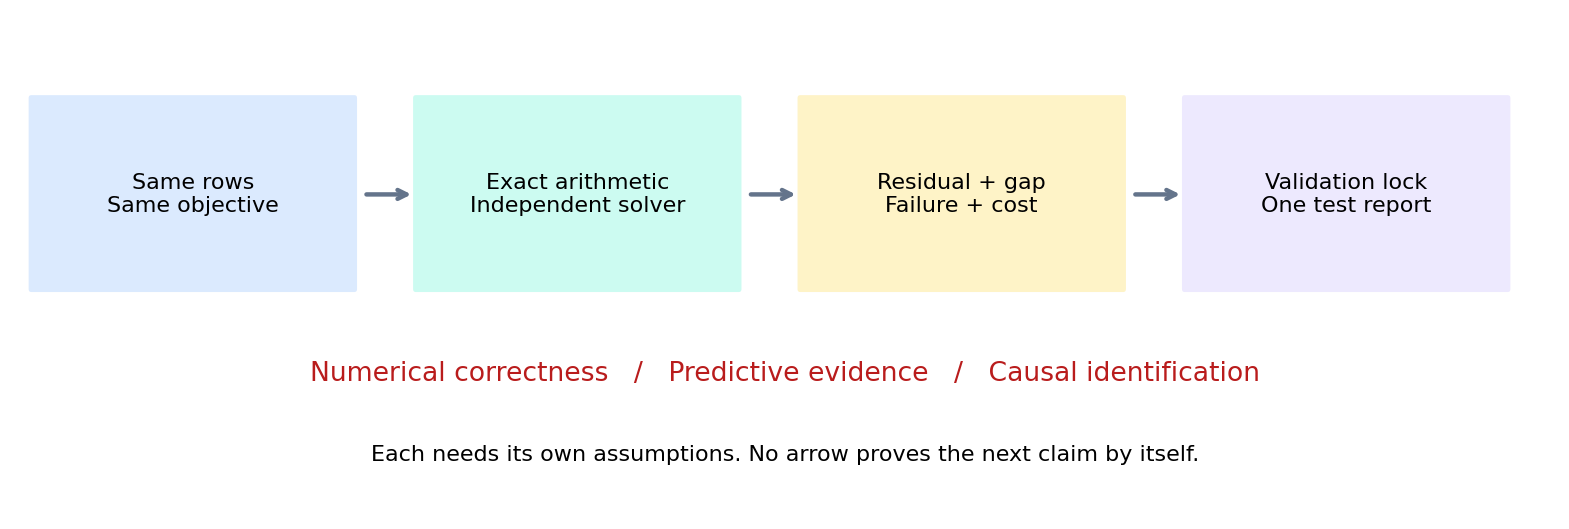

02_hand_chain.png


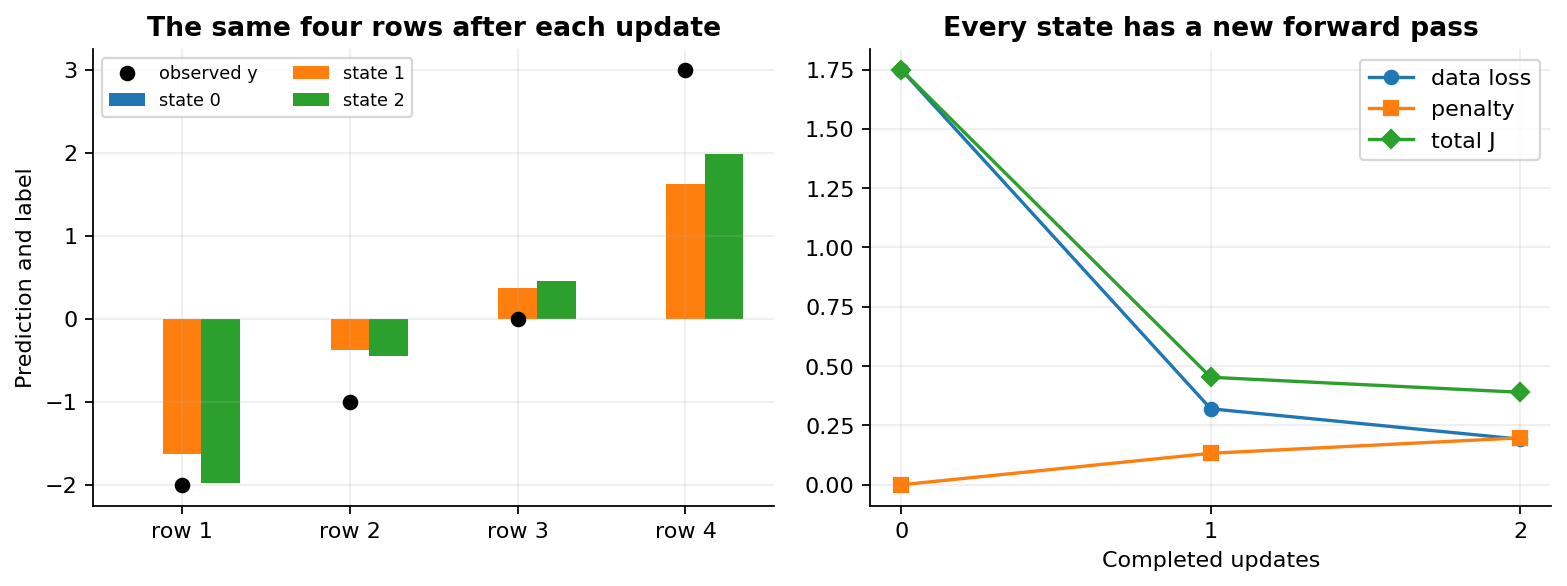

03_exact_and_iterative.png


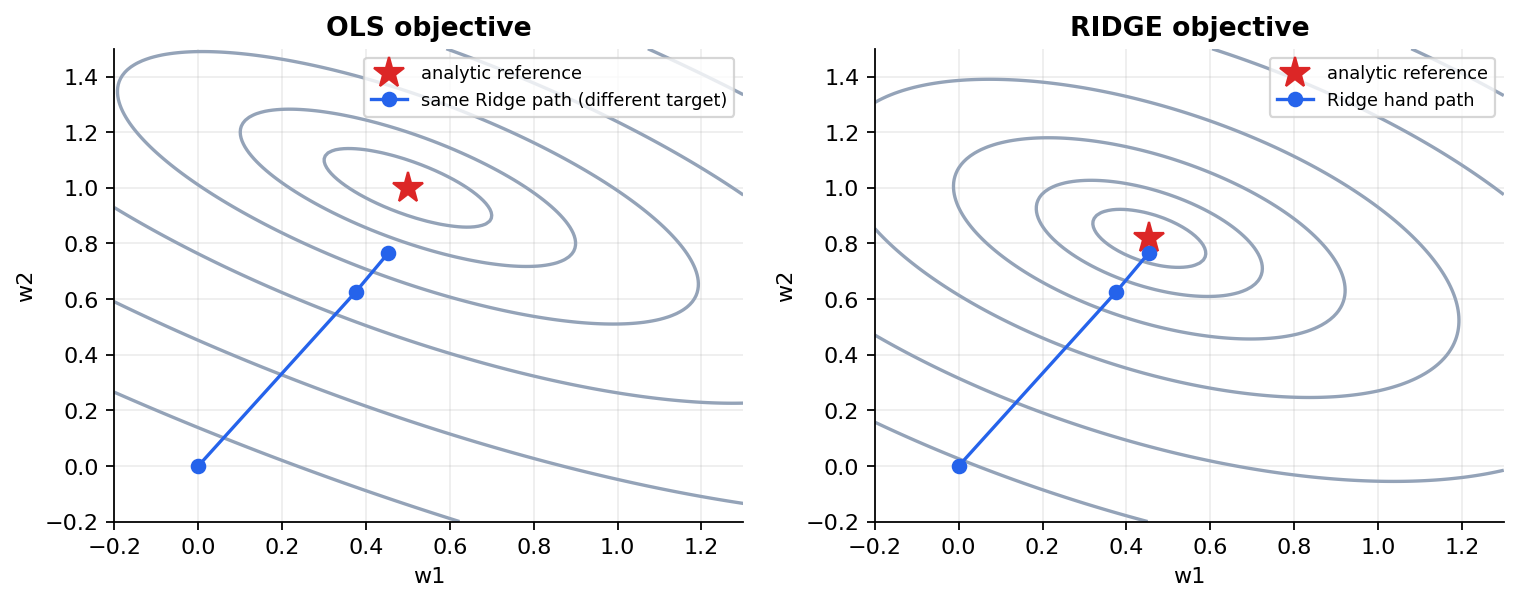

In [9]:
for path in figure_paths[0:3]:
    print(path.name)
    display(Image(data=path.read_bytes(), format="png"))


04_gradient_and_error.png


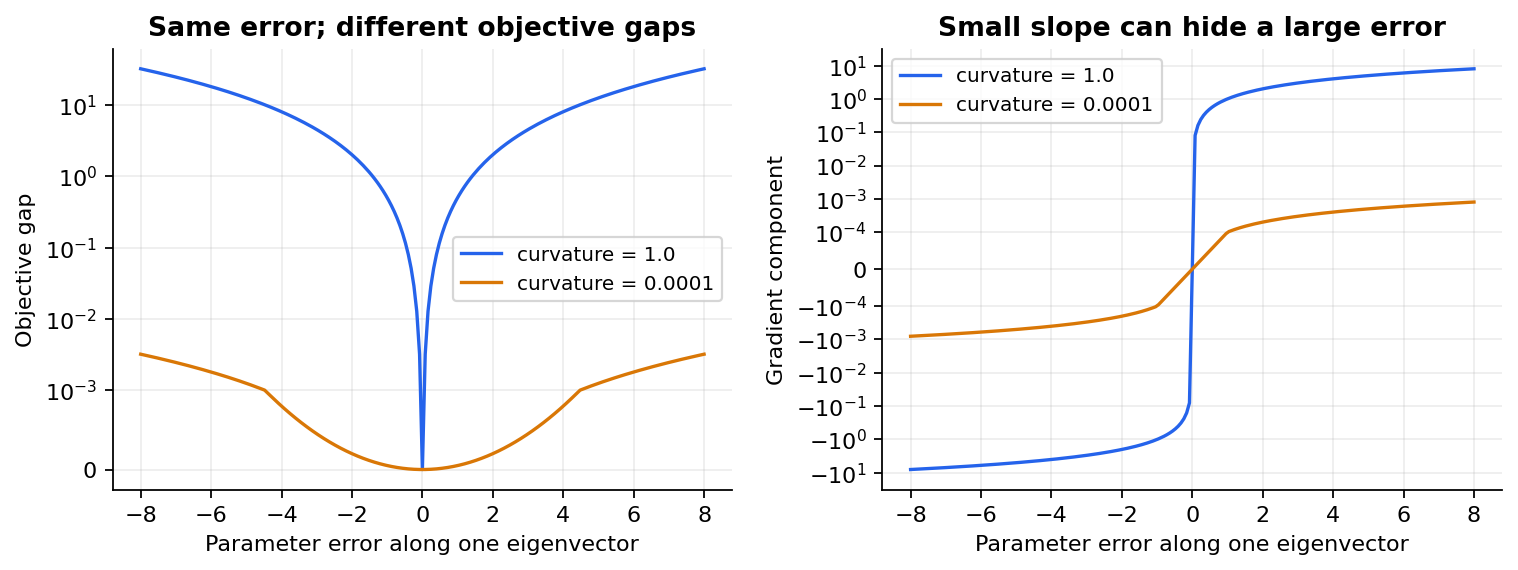

05_gradient_checks.png


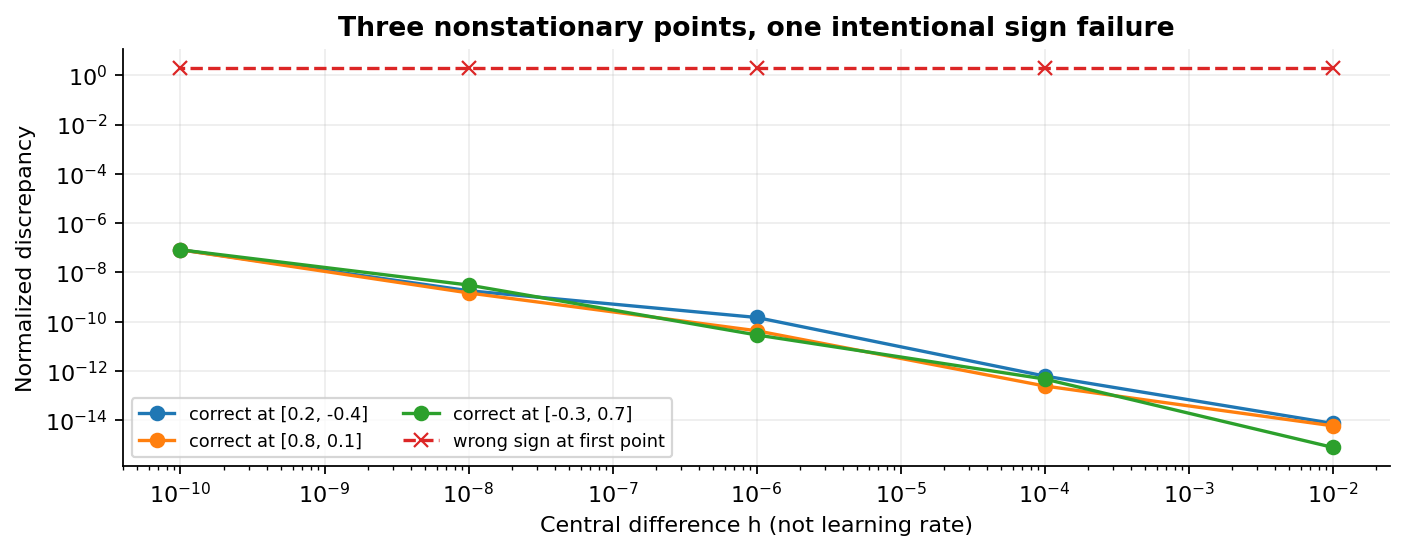

06_cost_convergence.png


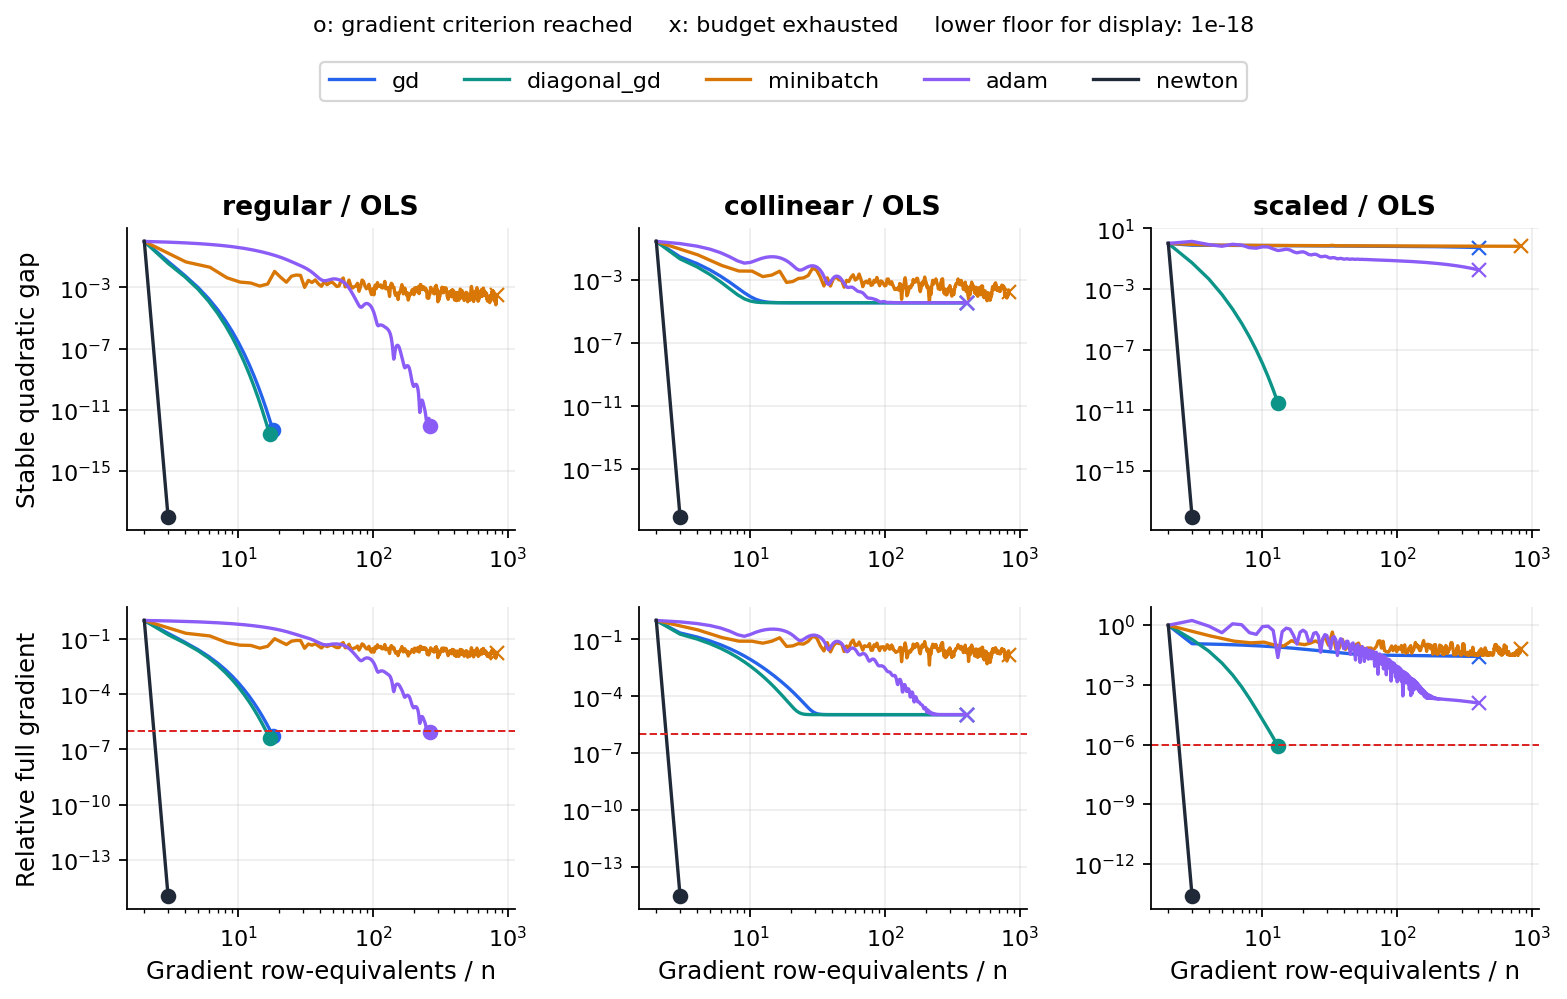

In [10]:
for path in figure_paths[3:6]:
    print(path.name)
    display(Image(data=path.read_bytes(), format="png"))


07_measured_cost.png


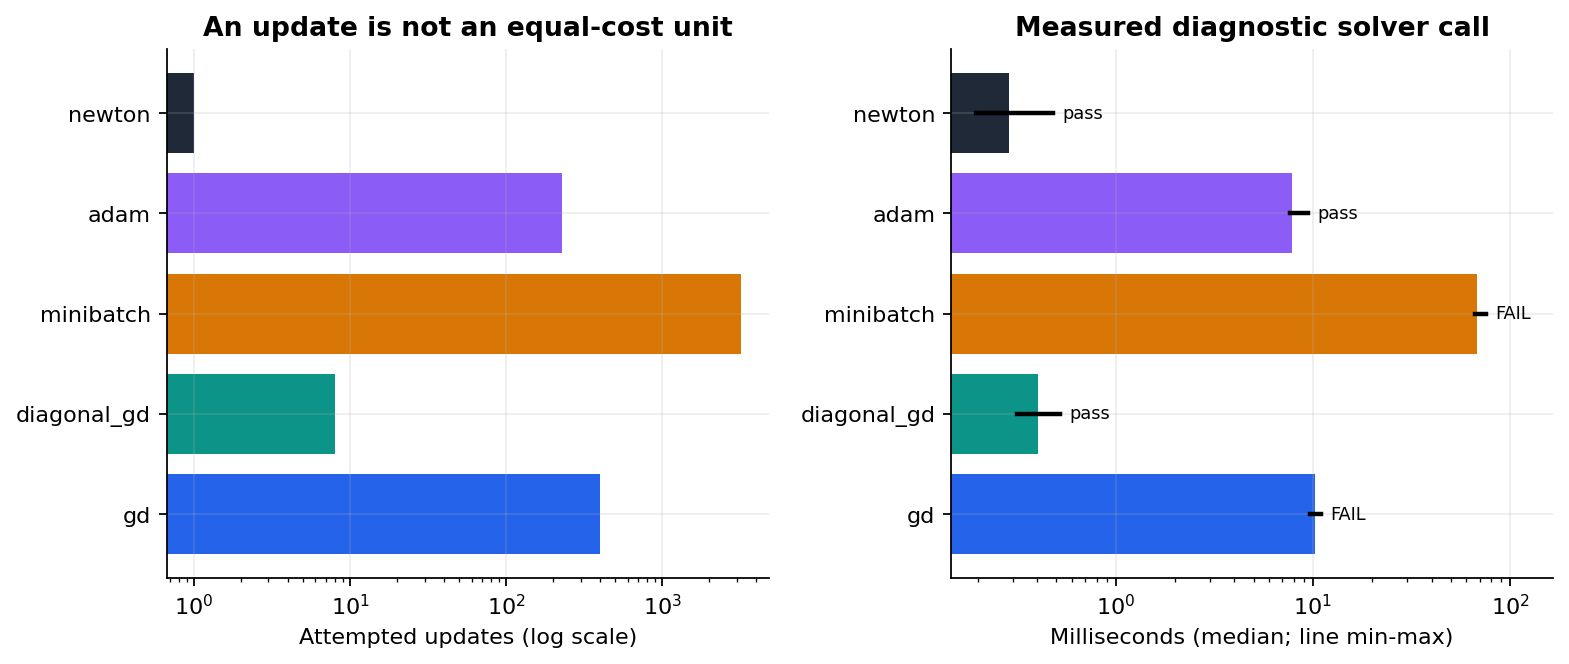

08_selection_lock.png


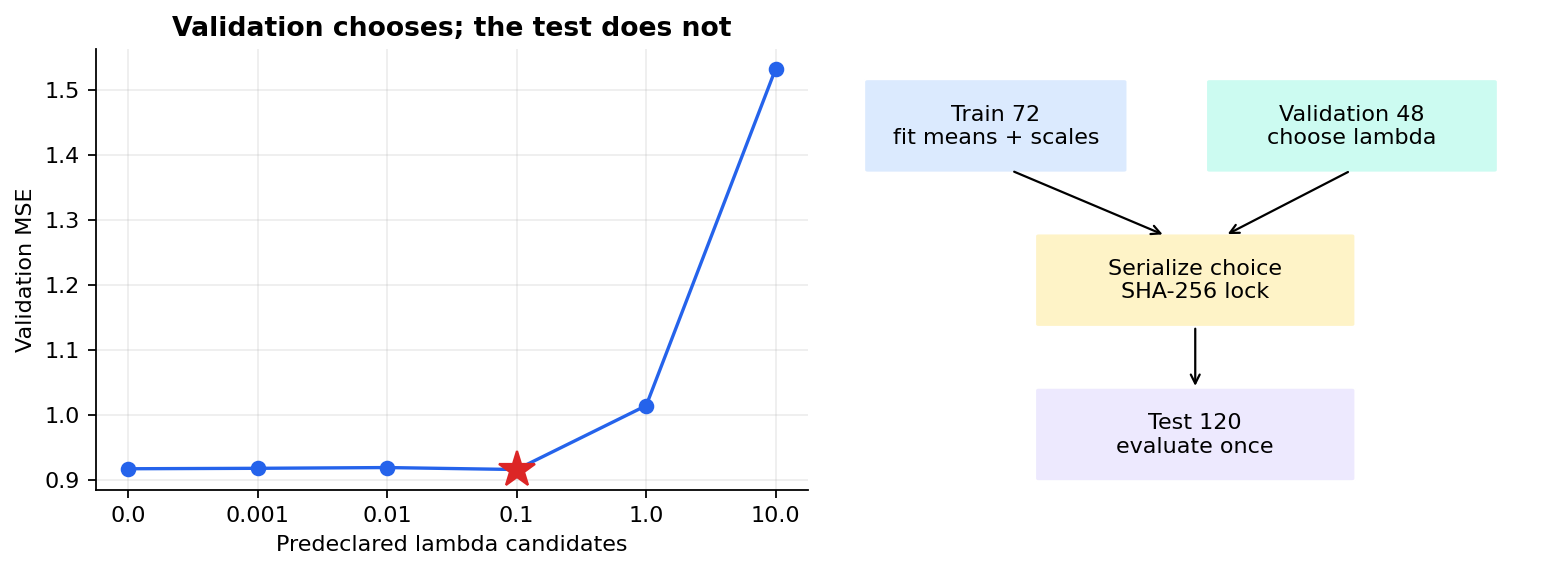

09_interval_objects.png


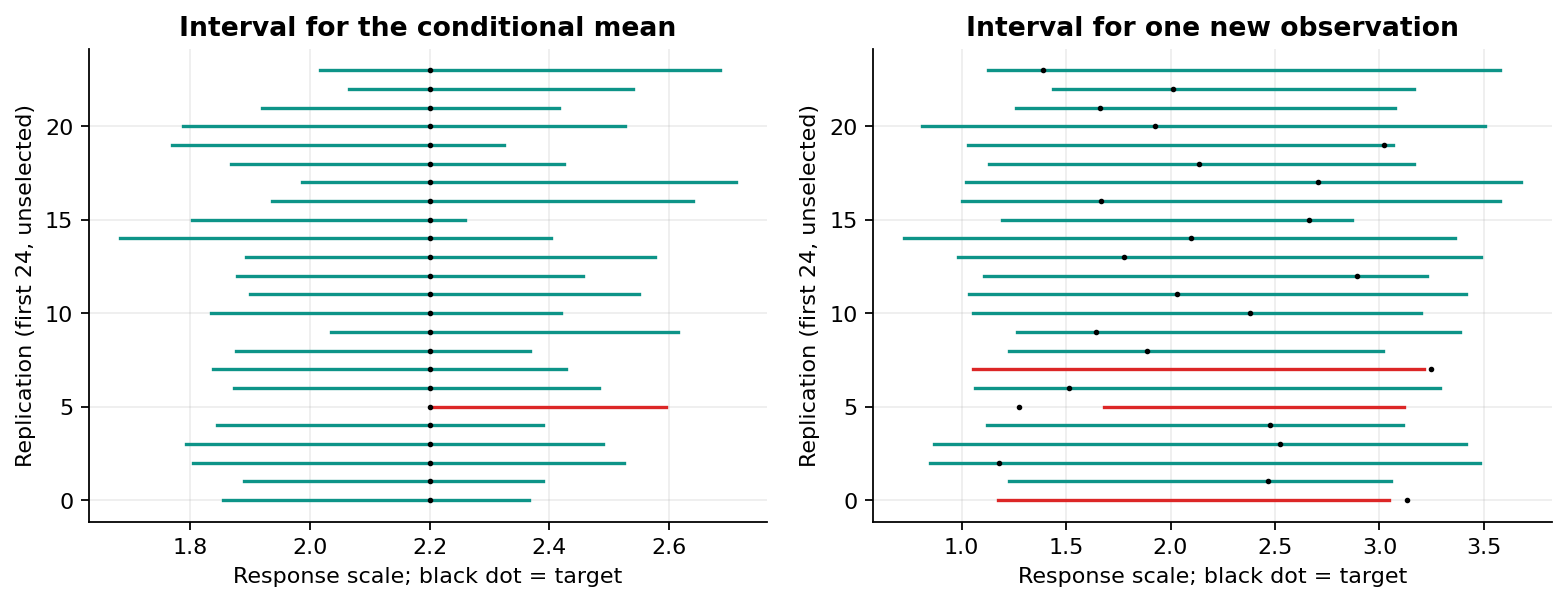

In [11]:
for path in figure_paths[6:9]:
    print(path.name)
    display(Image(data=path.read_bytes(), format="png"))


10_coverage_failure.png


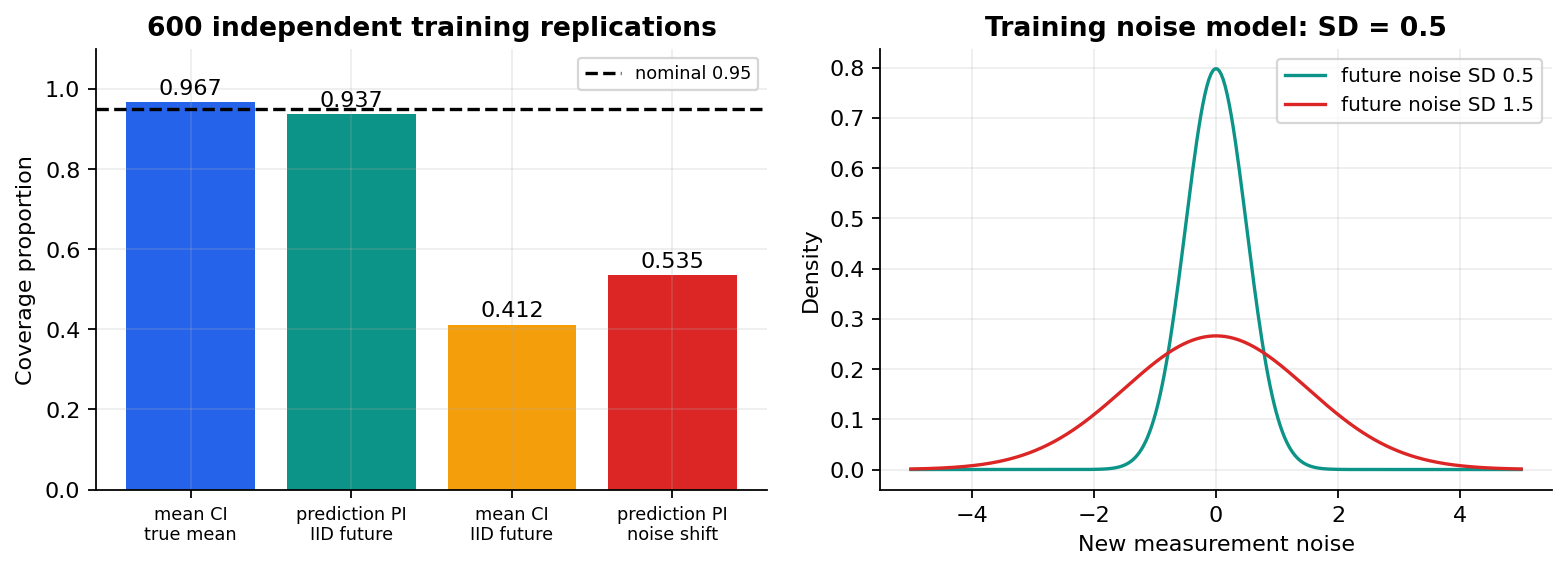

11_preconditioner.png


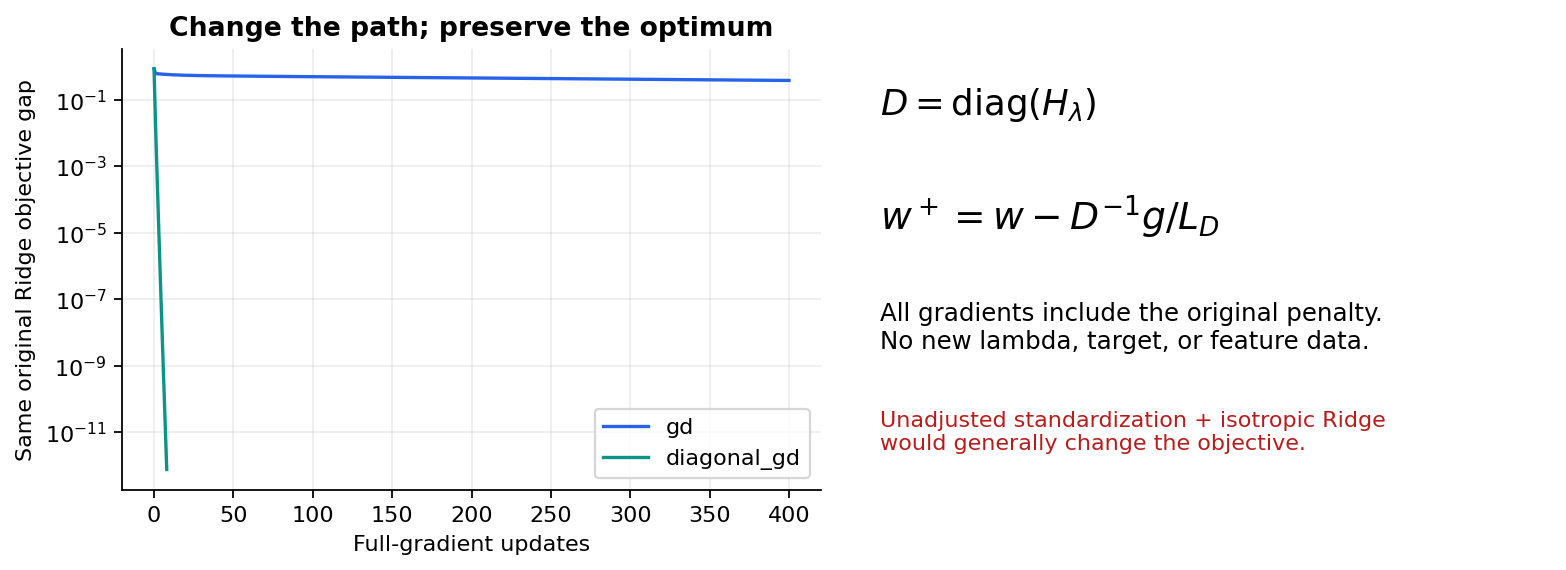

12_failed_attempt.png


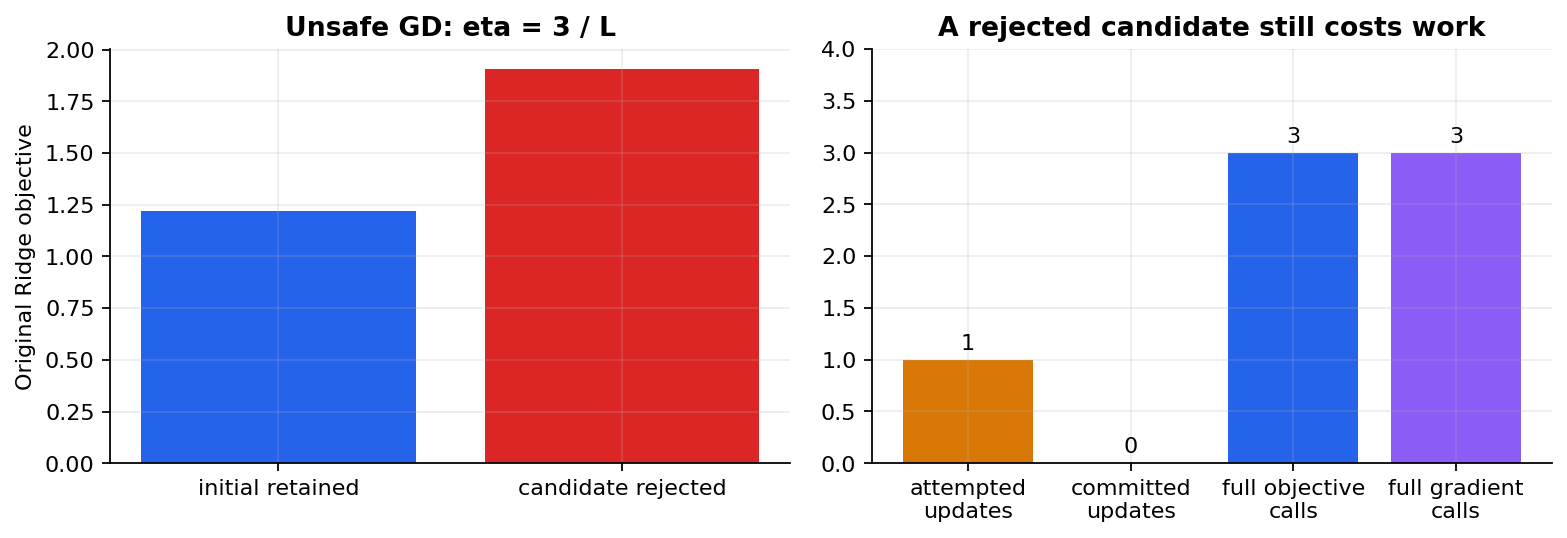

In [12]:
for path in figure_paths[9:12]:
    print(path.name)
    display(Image(data=path.read_bytes(), format="png"))


## 保存与结论
可重复的科学结果和波动的计时分别存档。这里没有给选择后Ridge附OLS区间，也不把回归系数解释成干预效应。

In [13]:
output = ROOT / "notebook_results"
output.mkdir(exist_ok=True)
e.atomic_json(output / "report.json", result)
e.atomic_json(output / "audit.json", audit_result)
e.atomic_json(output / "timing.json", timing)
print("Saved current report, audit, and timing; all failed paths retained.")


Saved current report, audit, and timing; all failed paths retained.